In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import least_squares
from scipy.stats import norm

In [2]:
from bracket_functions import create_initial_bracket, get_teams
from bracket_predictions import sequential_predictions, parallel_predictions
import bracket_predictions
import json
from scipy.stats import norm

In [3]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [89]:
YEAR = 2022
DATA_FILE_NAME = '/Users/Alex/Documents/MarchMadness/simple_{year}.csv'
ESPN_FILE = (
    'https://projects.fivethirtyeight.com/'
    'march-madness-api/{year}/fivethirtyeight_ncaa_forecasts.csv'
)

In [50]:
ORDER_OF_REGIONS = ['West', 'East', 'South', 'Midwest']  # This changes every year!

In [51]:
initial_bracket, data = create_initial_bracket(DATA_FILE_NAME.format(year=YEAR), ORDER_OF_REGIONS)

In [52]:
# Import 538's info
espn = pd.read_csv(ESPN_FILE.format(year=YEAR))
espn_slice = (espn['gender'] == 'mens') & (espn['forecast_date'] == max(espn.loc[lambda x: x["gender"] == "mens"]['forecast_date']))
team_info = espn[espn_slice][['team_id', 'team_name', 'team_region', 'team_seed']]

In [53]:
espn_data = espn[espn_slice]
espn_data.head()

,gender,forecast_date,playin_flag,rd1_win,rd2_win,rd3_win,rd4_win,rd5_win,rd6_win,rd7_win,results_to,team_alive,team_id,team_name,team_rating,team_region,team_seed,team_slot
0,mens,2022-04-02,0,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,0.67754,6,1,2305,Kansas,95.34000,Midwest,1,64
1,mens,2022-04-02,0,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,0.32246,6,1,153,North Carolina,91.24000,East,8,36
2,mens,2022-04-02,0,1.00000,1.00000,1.00000,1.00000,1.00000,0.00000,0.00000,7,0,150,Duke,92.67000,West,2,28
3,mens,2022-04-02,0,1.00000,1.00000,1.00000,1.00000,1.00000,0.00000,0.00000,7,0,222,Villanova,89.94000,South,2,124
4,mens,2022-04-02,0,1.00000,1.00000,1.00000,1.00000,0.00000,0.00000,0.00000,7,0,8,Arkansas,89.96000,West,4,12


In [90]:
def create_df_for_year(year, order_of_regions, champion_id):
    initial_bracket, data = create_initial_bracket(DATA_FILE_NAME.format(year=year), order_of_regions)
    espn = pd.read_csv(ESPN_FILE.format(year=year))
    espn_slice = (espn['gender'] == 'mens') & (espn['forecast_date'] == max(espn.loc[lambda x: x["gender"] == "mens"]['forecast_date']))
    espn_data = espn[espn_slice]
    espn_data.loc[champion_id, "rd7_win"] = 1
    espn_data.loc[1 - champion_id, "rd7_win"] = 0
    games = create_specific_bracket(initial_bracket, data, espn_data, perfect_bracket)
    df = create_df_from_games(games)
    df = pd.concat((df, add_previous_games(df)), axis=1)
    
    df["mean"] = (df["A_em"] - df["B_em"]) * (df["A_t"] + df["B_t"]) / 200
    df["outcome"] = (df["team_A"] == df["winner"]).astype(int)
    # Normalize by average tempo of all teams
    avg_tempo = data["AdjustT"].mean()
    df["tempo"] = ((df["A_t"] + df["B_t"]) / 2 - avg_tempo) / avg_tempo * 100
    return df

In [91]:
create_df_for_year(2022, ORDER_OF_REGIONS, 0)

/Users/Alex/opt/anaconda3/envs/py3/lib/python3.8/site-packages/pandas/core/indexing.py:966: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


,team_A,A_em,A_t,team_B,B_em,B_t,winner,previous_team_A_game,previous_team_B_game,mean,outcome,tempo
0,Gonzaga,32.95000,72.50000,Georgia State,1.66000,67.10000,Gonzaga,nan,nan,21.84042,1,4.40066
1,Boise State,16.13000,64.60000,Memphis,16.18000,70.30000,Memphis,nan,nan,-0.03373,0,0.88574
2,Connecticut,19.27000,64.90000,New Mexico State,10.01000,66.20000,New Mexico State,nan,nan,6.06993,0,-1.95611
3,Arkansas,19.06000,70.60000,Vermont,13.04000,65.00000,Arkansas,nan,nan,4.08156,1,1.40924
4,Alabama,17.38000,71.70000,Notre Dame,13.71000,65.60000,Notre Dame,nan,nan,2.51945,0,2.68060
...,...,...,...,...,...,...,...,...,...,...,...,...
58,Houston,26.51000,63.90000,Villanova,24.04000,62.60000,Villanova,52.00000,53.00000,1.56228,0,-5.39625
59,Kansas,25.63000,69.10000,Miami (FL),12.73000,67.30000,Kansas,54.00000,55.00000,8.79780,1,2.00753
60,Duke,23.79000,67.40000,North Carolina,16.11000,70.20000,North Carolina,56.00000,57.00000,5.28384,0,2.90495
61,Villanova,24.04000,62.60000,Kansas,25.63000,69.10000,Kansas,58.00000,59.00000,-1.04701,0,-1.50740


In [92]:
create_df_for_year(2021, ORDER_OF_REGIONS, 1)

/Users/Alex/opt/anaconda3/envs/py3/lib/python3.8/site-packages/pandas/core/indexing.py:966: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


,team_A,A_em,A_t,team_B,B_em,B_t,winner,previous_team_A_game,previous_team_B_game,mean,outcome,tempo
0,Gonzaga,36.62000,74.70000,Norfolk State,-3.70000,67.70000,Gonzaga,nan,nan,28.70784,1,4.85285
1,Oklahoma,16.69000,67.70000,Missouri,15.24000,68.70000,Oklahoma,nan,nan,0.98890,1,0.43489
2,Creighton,21.27000,69.00000,UC-Santa Barbara,12.23000,66.10000,Creighton,nan,nan,6.10652,1,-0.52233
3,Virginia,22.97000,60.10000,Ohio,10.77000,69.30000,Ohio,nan,nan,7.89340,0,-4.71939
4,Southern California,22.36000,67.30000,Drake,14.55000,66.60000,Southern California,nan,nan,5.22879,1,-1.40592
...,...,...,...,...,...,...,...,...,...,...,...,...
58,Baylor,29.56000,68.40000,Arkansas,21.61000,73.10000,Baylor,52.00000,53.00000,5.62462,1,4.19016
59,Oregon State,10.32000,65.40000,Houston,28.95000,64.90000,Houston,54.00000,55.00000,-12.13744,0,-4.05670
60,Gonzaga,36.62000,74.70000,UCLA,16.29000,64.60000,Gonzaga,56.00000,57.00000,14.15985,1,2.57024
61,Baylor,29.56000,68.40000,Houston,28.95000,64.90000,Baylor,58.00000,59.00000,0.40656,1,-1.84772


In [54]:
# Set championship result
espn_data.loc[0, "rd7_win"] = 1
espn_data.loc[1, "rd7_win"] = 0

/Users/Alex/opt/anaconda3/envs/py3/lib/python3.8/site-packages/pandas/core/indexing.py:966: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


In [55]:
# # Set championship result
# espn_data.loc[0, "rd6_win"] = 1
# espn_data.loc[0, "rd7_win"] = 1
# espn_data.loc[1, "rd6_win"] = 1
# espn_data.loc[1, "rd7_win"] = 0
# espn_data.loc[2, "rd6_win"] = 0
# espn_data.loc[2, "rd7_win"] = 0
# espn_data.loc[3, "rd6_win"] = 0
# espn_data.loc[3, "rd7_win"] = 0

In [58]:
def create_specific_bracket(initial_bracket, data, espn, bracket_type_func):
    bracket = initial_bracket.copy()
    games = []
    rounds = ['64', '32', '16', '8', '4', '2', '1']
    for round_ in range(6):
        gap = 2**(round_ + 1)  # how far apart two teams could be for a given round
        for top_team in range(0, len(bracket), gap):
            pyths = get_teams(top_team, gap, bracket, rounds, round_, data)
            winner_num, winner_name = bracket_type_func(pyths, data, espn, round_, bracket)
            bracket.loc[winner_num, rounds[round_ + 1]] = winner_name  # write in the winner
            games.append((pyths, (winner_num, winner_name)))
    return games

In [59]:
def get_team_ids(pyths, data):
    return data.loc[data["64"].isin([i[1] for i in pyths])]["team_id"].tolist()


def get_winner(team_ids, data, round_):
    df = data.loc[lambda x: x["team_id"].isin(team_ids)]
    return df.loc[df[f"rd{round_ + 2}_win"].idxmax()]["team_name"]


def perfect_bracket(pyths, data, espn, round_, *args):
    team_ids = get_team_ids(pyths, data)
    winner_name = get_winner(team_ids, espn, round_)
    winner_num = [i[0] for i in pyths if i[1] == winner_name][0]
    return winner_num, winner_name

In [60]:
games = create_specific_bracket(initial_bracket, data, espn_data, perfect_bracket)

In [61]:
def create_df_from_games(games):
    rows = []
    for game in games:
        rows.append({
            "team_A": game[0][0][1],
            "A_em": game[0][0][2],
            "A_t": game[0][0][3],
            "team_B": game[0][1][1],
            "B_em": game[0][1][2],
            "B_t": game[0][1][3],
            "winner": game[1][1],
        })
    return pd.DataFrame(rows)

In [62]:
def add_previous_games(df):
    all_previous_games = []
    for i, row in df.iterrows():
        previous_games = {}
        for team in ["team_A", "team_B"]:
            previous_game = df[:i].loc[
                lambda x: (x["team_A"] == row[team]) | (x["team_B"] == row[team])
            ].tail(1)
            if len(previous_game) > 0:
                previous_games[f"previous_{team}_game"] = previous_game.index[0]
            else:
                previous_games[f"previous_{team}_game"] = np.nan
        all_previous_games.append(previous_games)
    return pd.DataFrame(all_previous_games)

In [63]:
df = create_df_from_games(games)
df = pd.concat((df, add_previous_games(df)), axis=1)
df["outcome"] = (df["team_A"] == df["winner"]).astype(int)
df

,team_A,A_em,A_t,team_B,B_em,B_t,winner,previous_team_A_game,previous_team_B_game,outcome
0,Gonzaga,32.95000,72.50000,Georgia State,1.66000,67.10000,Gonzaga,nan,nan,1
1,Boise State,16.13000,64.60000,Memphis,16.18000,70.30000,Memphis,nan,nan,0
2,Connecticut,19.27000,64.90000,New Mexico State,10.01000,66.20000,New Mexico State,nan,nan,0
3,Arkansas,19.06000,70.60000,Vermont,13.04000,65.00000,Arkansas,nan,nan,1
4,Alabama,17.38000,71.70000,Notre Dame,13.71000,65.60000,Notre Dame,nan,nan,0
...,...,...,...,...,...,...,...,...,...,...
58,Houston,26.51000,63.90000,Villanova,24.04000,62.60000,Villanova,52.00000,53.00000,0
59,Kansas,25.63000,69.10000,Miami (FL),12.73000,67.30000,Kansas,54.00000,55.00000,1
60,Duke,23.79000,67.40000,North Carolina,16.11000,70.20000,North Carolina,56.00000,57.00000,0
61,Villanova,24.04000,62.60000,Kansas,25.63000,69.10000,Kansas,58.00000,59.00000,0


In [64]:
df["mean"] = (df["A_em"] - df["B_em"]) * (df["A_t"] + df["B_t"]) / 200
df["outcome"] = (df["team_A"] == df["winner"]).astype(int)
# Normalize by average tempo of all teams
avg_tempo = data["AdjustT"].mean()
df["tempo"] = ((df["A_t"] + df["B_t"]) / 2 - avg_tempo) / avg_tempo * 100
df.head()

,team_A,A_em,A_t,team_B,B_em,B_t,winner,previous_team_A_game,previous_team_B_game,outcome,mean,tempo
0,Gonzaga,32.95000,72.50000,Georgia State,1.66000,67.10000,Gonzaga,nan,nan,1,21.84042,4.40066
1,Boise State,16.13000,64.60000,Memphis,16.18000,70.30000,Memphis,nan,nan,0,-0.03373,0.88574
2,Connecticut,19.27000,64.90000,New Mexico State,10.01000,66.20000,New Mexico State,nan,nan,0,6.06993,-1.95611
3,Arkansas,19.06000,70.60000,Vermont,13.04000,65.00000,Arkansas,nan,nan,1,4.08156,1.40924
4,Alabama,17.38000,71.70000,Notre Dame,13.71000,65.60000,Notre Dame,nan,nan,0,2.51945,2.68060


In [65]:
df["tempo"].describe()

count   63.00000
mean     0.23523
std      2.75801
min     -5.77017
25%     -1.43261
50%      0.06310
75%      1.93274
max      7.01816
Name: tempo, dtype: float64

In [66]:
def _update_rating(rating, team, df, row, k, sigma):
    if np.isnan(row[f"previous_{team}_game"]):
        return rating
    else:
        previous_game = df.loc[row[f"previous_{team}_game"]]
        previous_mean = (
            (
                _update_rating(
                    previous_game["A_em"], "team_A", df, previous_game, k, sigma
                ) - _update_rating(
                    previous_game["B_em"], "team_B", df, previous_game, k, sigma
                )
            ) * (previous_game["A_t"] + previous_game["B_t"]) / 200
        )
        if isinstance(sigma, pd.Series):
            sigma = sigma.loc[row.name]
        if row[team] == previous_game["team_A"]:
            prob_win = norm(0, sigma).cdf(previous_mean)
        elif row[team] == previous_game["team_B"]:
            prob_win = 1 - norm(0, sigma).cdf(previous_mean)
        else:
            raise Exception("wut")
        new_rating = rating + k * (1 - prob_win)
        return new_rating

In [67]:
def _compute_prob(row, team_name, mean, sigma):
    if isinstance(sigma, pd.Series):
        sigma = sigma.loc[row.name]
    prob = norm(0, sigma).cdf(mean)
    if row["team_A"] == team_name:
        return prob
    elif row["team_B"] == team_name:
        return 1 - prob
    else:
        raise Exception("wut")

In [68]:
def _compute_expected_rating(row, A_em, B_em, A_t, B_t, sigma):
    if isinstance(sigma, pd.Series):
        sigma = sigma.loc[row.name]
    mean = (A_em - B_em) * (A_t + B_t) / 200
    prob = norm(0, sigma).cdf(mean)
    return (prob * A_em + (1 - prob) * B_em), (prob * A_t + (1 - prob) * B_t)

In [69]:
def _prob_team_in_game(team_name, df, row, k, sigma):
    previous_team_id = "team_A" if row["team_A"] == team_name else "team_B"
    if np.isnan(row[f"previous_{previous_team_id}_game"]):
        return 1
    else:
        previous_game = df.loc[row[f"previous_{previous_team_id}_game"]]
        previous_mean = (
            (
                _update_rating(
                    previous_game["A_em"], "team_A", df, previous_game, k, sigma
                ) - _update_rating(
                    previous_game["B_em"], "team_B", df, previous_game, k, sigma
                )
            ) * (previous_game["A_t"] + previous_game["B_t"]) / 200
        )
        return _compute_prob(previous_game, team_name, previous_mean, sigma) * _prob_team_in_game(team_name, df, previous_game, k, sigma)

In [70]:
def _expected_opponent_rating(df, row, k, sigma, first_opponent_em, first_opponent_t):
    if row is None:
        return first_opponent_em, first_opponent_t
    if np.isnan(row[f"previous_team_A_game"]):
        return _compute_expected_rating(row, row["A_em"], row["B_em"], row["A_t"], row["B_t"], sigma)
    else:
        A_em, A_t = _expected_opponent_rating(df, df.loc[row[f"previous_team_A_game"]], k, sigma, first_opponent_em, first_opponent_t)
        B_em, B_t = _expected_opponent_rating(df, df.loc[row[f"previous_team_B_game"]], k, sigma, first_opponent_em, first_opponent_t)
        A_em = _update_rating(
            A_em, "team_A", df, df.loc[row[f"previous_team_A_game"]], k, sigma
        )
        B_em = _update_rating(
            B_em, "team_B", df, df.loc[row[f"previous_team_B_game"]], k, sigma
        )
        return _compute_expected_rating(row, A_em, B_em, A_t, B_t, sigma)

In [71]:
def _get_previous_row(combined, row):
    if np.isnan(row[f"previous_team_A_game"]):
        return None
    elif row["outcome"]:
        return combined.loc[row["previous_team_B_game"]]
    else:
        return combined.loc[row["previous_team_A_game"]]

In [72]:
def _update_rating_expected(rating, team_name, df, row, k, sigma):
    if np.isnan(row[f"previous_team_A_game"]):
        return rating
    else:
        if isinstance(sigma, pd.Series):
            sigma = sigma.loc[row.name]
        previous_team_id = "team_A" if row["team_A"] == team_name else "team_B"
        previous_game = df.loc[row[f"previous_{previous_team_id}_game"]]
        if team_name == previous_game["team_A"]:
            previous_mean = (
                (
                    _update_rating_expected(
                        previous_game["A_em"], team_name, df, previous_game, k, sigma
                    ) - previous_game["expected_em"]
                ) * (previous_game["A_t"] + previous_game["expected_t"]) / 200
            )
            prob_win = norm(0, sigma).cdf(previous_mean)
        elif team_name == previous_game["team_B"]:
            previous_mean = (
                (
                    previous_game["expected_em"] - _update_rating_expected(
                        previous_game["B_em"], team_name, df, previous_game, k, sigma
                    )
                ) * (previous_game["expected_t"] + previous_game["B_t"]) / 200
            )
            prob_win = 1 - norm(0, sigma).cdf(previous_mean)
        else:
            raise Exception("wut")
        new_rating = rating + k * (1 - prob_win)
        return new_rating

In [73]:
def _get_pts_from_game_id(row):
    if row.name < 32:
        return 10
    elif row.name < 48:
        return 20
    elif row.name < 56:
        return 40
    elif row.name < 60:
        return 80
    elif row.name < 62:
        return 160
    elif row.name == 62:
        return 320
    else:
        raise Exception("wut")

In [136]:
def create_data(df, k, sigma):
    combined = df.copy()
    expected_opponents = combined.apply(
        lambda row: _expected_opponent_rating(
            df=combined,
            row=_get_previous_row(combined, row),
            k=k,
            sigma=sigma,
            first_opponent_em=row["B_em"] if row["outcome"] else row["A_em"],
            first_opponent_t=row["B_t"] if row["outcome"] else row["A_t"],
        ),
        axis=1
    ).apply(pd.Series).rename(columns={0: "expected_em", 1: "expected_t"})
    combined = pd.concat((combined, expected_opponents), axis=1)
    probs = pd.DataFrame(
        combined.apply(
            lambda row: _prob_team_in_game(
                team_name=row["team_A"] if row["outcome"] else row["team_B"],
                df=combined,
                row=row,
                k=k,
                sigma=sigma,
            ),
            axis=1
        ), columns=["prob_team_in_game"]
    )
    combined = pd.concat((combined, probs), axis=1)
    updated_rating = pd.DataFrame(
        combined.apply(
            lambda row: _update_rating_expected(
                rating=row["A_em"] if row["outcome"] else row["B_em"],
                team_name=row["team_A"] if row["outcome"] else row["team_B"],
                df=combined,
                row=row,
                k=k,
                sigma=sigma,
            ),
            axis=1
        ), columns=["updated_rating"]
    )
    combined = pd.concat((combined, updated_rating), axis=1)
    pts = pd.DataFrame(
        combined.apply(lambda row: _get_pts_from_game_id(row), axis=1),
        columns=["pts"],
    )
    combined = pd.concat((combined, pts), axis=1)
    return combined

Scoring a bracket
- For each game
    - Take the winner as team_A
    - Value of game is Prob(team_A wins) * game pts
    - Prob(team_A wins) = Prob(team_A there) * Prob(team_A > team_B)
    - Prob(team_A > team_B) = P

In [137]:
def _score_games(row, sigma):
    team_t = row["A_t"] if row["outcome"] else row["B_t"]
    mean = (row["updated_rating"] - row["expected_em"]) * (team_t + row["expected_t"]) / 200
    if isinstance(sigma, pd.Series):
        sigma = sigma.loc[row.name]
    prob_win = norm(0, sigma).cdf(mean)
    return row["prob_team_in_game"] * prob_win * row["pts"]

In [138]:
from sklearn.metrics import log_loss

In [139]:
def _score_games_log_loss(row, sigma):
    team_t = row["A_t"] if row["outcome"] else row["B_t"]
    mean = (row["updated_rating"] - row["expected_em"]) * (team_t + row["expected_t"]) / 200
    if isinstance(sigma, pd.Series):
        sigma = sigma.loc[row.name]
    prob_win = norm(0, sigma).cdf(mean)
    return np.log(row["prob_team_in_game"] * prob_win) * row["pts"]

In [155]:
def score_method(df, k, sigma):
    if "year" in df.columns:
        expected_pts_list = []
        for year in df["year"].unique():
            year_slice = df["year"] == year
            combined = create_data(df.loc[year_slice], k, sigma.loc[year_slice])
            expected_pts_list.append(
                combined.apply(
                    lambda row: _score_games_log_loss(row=row, sigma=sigma.loc[year_slice]),
                    axis=1
                )
            )
        expected_pts = pd.concat(expected_pts_list)
    else:
        combined = create_data(df, k, sigma)
        expected_pts = combined.apply(
            lambda row: _score_games_log_loss(row=row, sigma=sigma),
            axis=1
        )
    if not np.isfinite(expected_pts).all():
        return NULL_VALUE
    return expected_pts.sum()

In [149]:
from bayes_opt import BayesianOptimization
from functools import partial

In [156]:
def objective(intercept, slope):
    k = 0
    sigma = intercept + slope * df["tempo"]
    if (sigma <= 0).any():
        return NULL_VALUE
    return score_method(df=df, k=k, sigma=sigma)

In [151]:
df = pd.concat(
    (
        create_df_for_year(2021, ORDER_OF_REGIONS, 1).assign(year=2021),
        create_df_for_year(2022, ORDER_OF_REGIONS, 0).assign(year=2022),
    )
)

In [157]:
NULL_VALUE = -8e3

In [158]:
# Bounded region of parameter space
pbounds = {
    'intercept': (5, 15),
    'slope': (-3, 3),
}

optimizer = BayesianOptimization(
    f=objective,
    pbounds=pbounds,
    random_state=42,
)

In [159]:
optimizer.probe(
    params={"intercept": 9, "slope": 0},
    lazy=True,
)

In [160]:
%%time
optimizer.maximize(
    init_points=200,
    n_iter=200,
#     init_points=20,
#     n_iter=20,
#     init_points=20,
#     n_iter=20,
)

|   iter    |  target   | intercept |   slope   |
-------------------------------------------------
|  1        | -6.436e+0 |  9.0      |  0.0      |
|  2        | -8e+03    |  8.745    |  2.704    |
|  3        | -6.338e+0 |  12.32    |  0.592    |
|  4        | -8e+03    |  6.56     | -2.064    |
|  5        | -8e+03    |  5.581    |  2.197    |
|  6        | -6.408e+0 |  11.01    |  1.248    |
|  7        | -8e+03    |  5.206    |  2.819    |
|  8        | -8.403e+0 |  13.32    | -1.726    |
|  9        | -8e+03    |  6.818    | -1.9      |
|  10       | -6.528e+0 |  8.042    |  0.1485   |
|  11       | -1.53e+04 |  9.319    | -1.253    |
|  12       | -8e+03    |  11.12    | -2.163    |
|  13       | -8.196e+0 |  7.921    | -0.8018   |
|  14       | -8e+03    |  9.561    |  1.711    |
|  15       | -6.871e+0 |  6.997    |  0.08541  |
|  16       | -8e+03    |  10.92    | -2.721    |
|  17       | -8e+03    |  11.08    | -1.977    |
|  18       | -8e+03    |  5.651    |  2.693    |


In [161]:
optimizer.max

{'target': -6293.157054011802,
 'params': {'intercept': 11.25824373262967, 'slope': 0.21340825901277594}}

In [170]:
num_points = 1000
eval_points = pd.DataFrame({
    "intercept": np.random.uniform(8, 15, num_points),
    "slope": np.random.uniform(-1.5, 1.5, num_points),
})

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

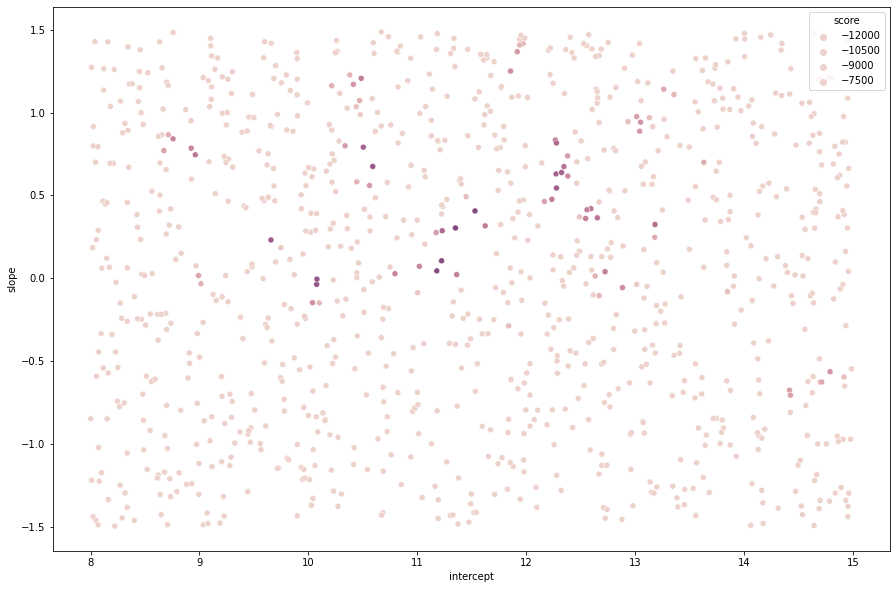

In [174]:
%matplotlib inline
plot_data = pd.concat(
    (
        eval_points,
        pd.Series(optimizer._gp.predict(eval_points), name="score")
    ),
    axis=1
)
plt.figure(figsize=(15, 10))
sns.scatterplot(x="intercept", y="slope", hue="score", hue_norm=(-6500, -6200), data=plot_data)

In [83]:
def manual_score(df, k, sigma):
    combined = create_data(df, k, sigma)
    expected_pts = combined.apply(
        lambda row: _score_games(row=row, sigma=sigma),
        axis=1
    )
    expected_log_loss = combined.apply(
        lambda row: _score_games_log_loss(row=row, sigma=sigma),
        axis=1
    )
    if not type(sigma) == pd.Series:
        sigma = pd.Series([sigma] * len(df))
    data = pd.concat((expected_pts, expected_log_loss, sigma), axis=1)
    data.columns = ["expected_points", "log_loss", "sigma"]
    return {
        "expected_points": expected_pts.sum(),
        "log_loss": expected_log_loss.sum(),
        "data": data,
    }

In [139]:
(optimizer.max["params"]["intercept"] + optimizer.max["params"]["slope"] * df["tempo"]).describe()

count   63.00000
mean    12.40152
std      5.20799
min      1.06144
25%      9.25212
50%     12.07650
75%     15.60696
max     25.20984
Name: tempo, dtype: float64

In [141]:
manual_score(
    df=df,
    k=0,
    sigma=optimizer.max["params"]["intercept"] + optimizer.max["params"]["slope"] * df["tempo"]
)

{'expected_points': 587.0217988133764,
 'log_loss': -3410.0460352707682,
 'data':     expected_points   log_loss    sigma
 0           8.59399   -1.51521 20.26718
 1           5.00987   -6.91175 13.62990
 2           2.31310  -14.63996  8.26359
 3           6.09957   -4.94367 14.61843
 4           4.41157   -8.18354 17.01915
 ..              ...        ...      ...
 58         56.86992  -27.30081  1.76753
 59         23.03984  -99.58412 15.74818
 60          2.97410 -637.63706 17.44281
 61         31.02600 -262.45572  9.11090
 62         31.17769 -745.15783 19.84353
 
 [63 rows x 3 columns]}

In [84]:
manual_score(
    df=df,
    k=0,
    sigma=10 - 0.21 * df["tempo"]
)

{'expected_points': 573.8669672812475,
 'log_loss': -3679.328389523128,
 'data':     expected_points   log_loss    sigma
 0           9.91945   -0.08087  9.07586
 1           5.01371   -6.90409  9.81399
 2           2.79932  -12.73207 10.41078
 3           6.62978   -4.11014  9.70406
 4           3.94745   -9.29516  9.43707
 ..              ...        ...      ...
 58         17.63493 -120.97159 11.13321
 59         33.93466  -68.60717  9.57842
 60          0.88336 -831.87158  9.38996
 61         47.80389 -193.29069 10.31655
 62         44.55225 -630.93068  9.12298
 
 [63 rows x 3 columns]}

In [85]:
manual_score(
    df=df,
    k=0,
    sigma=11
)

{'expected_points': 560.5594044401716,
 'log_loss': -3543.85349836992,
 'data':     expected_points   log_loss  sigma
 0           9.76455   -0.23826     11
 1           5.01223   -6.90704     11
 2           2.90539  -12.36019     11
 3           6.44700   -4.38970     11
 4           4.09418   -8.93018     11
 ..              ...        ...    ...
 58         18.07442 -119.00232     11
 59         30.60083  -76.87997     11
 60          1.50589 -746.52623     11
 61         42.54568 -211.93527     11
 62         42.55643 -645.59683     11
 
 [63 rows x 3 columns]}

In [144]:
manual_score(
    df=df,
    k=0,
    sigma=9.17
)

{'expected_points': 592.3725723837695,
 'log_loss': -3671.176843770224,
 'data':     expected_points   log_loss   sigma
 0           9.91384   -0.08653 9.17000
 1           5.01467   -6.90217 9.17000
 2           2.54007  -13.70394 9.17000
 3           6.71876   -3.97682 9.17000
 4           3.91754   -9.37121 9.17000
 ..              ...        ...     ...
 58         19.92474 -111.20517 9.17000
 59         35.30193  -65.44712 9.17000
 60          0.85293 -837.48026 9.17000
 61         50.58201 -184.25245 9.17000
 62         48.16032 -606.01135 9.17000
 
 [63 rows x 3 columns]}